<a href="https://colab.research.google.com/github/estein9825/cpre5600/blob/main/EthanCollinsPeter_6500_FinalProject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TeleDAL Experiment Setup

## Install + imports

In [2]:
!pip -q install transformers datasets accelerate

In [3]:
import torch
import os, re, json, math, random
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
from transformers import AutoTokenizer, AutoModel
import keras

# Retrieve and Prepare Data

## Obtain HDFS and BGL datasets

In [4]:
# Create a workspace
!mkdir -p /content/loghub_data
%cd /content/loghub_data

# Download HDFS v1 and BGL from LogHub's Zenodo bundle
!wget -O HDFS_1.tar.gz "https://zenodo.org/records/3227177/files/HDFS_1.tar.gz?download=1"
!wget -O BGL.tar.gz    "https://zenodo.org/records/3227177/files/BGL.tar.gz?download=1"

# Extract
!tar -xzf HDFS_1.tar.gz
!tar -xzf BGL.tar.gz

# See what you got
!find /content/loghub_data -maxdepth 3 -type f | sort | sed -n '1,200p'

/content/loghub_data
--2026-05-05 19:12:15--  https://zenodo.org/records/3227177/files/HDFS_1.tar.gz?download=1
Resolving zenodo.org (zenodo.org)... 188.184.103.118, 188.185.43.153, 188.184.98.114, ...
Connecting to zenodo.org (zenodo.org)|188.184.103.118|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 161886385 (154M) [application/octet-stream]
Saving to: ‘HDFS_1.tar.gz’

HDFS_1.tar.gz       100%[===================>] 154.39M  27.0MB/s    in 6.5s    

2026-05-05 19:12:30 (23.8 MB/s) - ‘HDFS_1.tar.gz’ saved [161886385/161886385]

--2026-05-05 19:12:30--  https://zenodo.org/records/3227177/files/BGL.tar.gz?download=1
Resolving zenodo.org (zenodo.org)... 188.184.103.118, 188.185.43.153, 188.184.98.114, ...
Connecting to zenodo.org (zenodo.org)|188.184.103.118|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 62936967 (60M) [application/octet-stream]
Saving to: ‘BGL.tar.gz’

BGL.tar.gz          100%[===================>]  60.02M  20.2MB/s 

#### Original Data lines

In [5]:
with open("/content/loghub_data/HDFS.log", "r", encoding="utf-8", errors="ignore") as f:
    for i, line in enumerate(f):
        print(line.rstrip())
        if i >= 19:
            break

081109 203518 143 INFO dfs.DataNode$DataXceiver: Receiving block blk_-1608999687919862906 src: /10.250.19.102:54106 dest: /10.250.19.102:50010
081109 203518 35 INFO dfs.FSNamesystem: BLOCK* NameSystem.allocateBlock: /mnt/hadoop/mapred/system/job_200811092030_0001/job.jar. blk_-1608999687919862906
081109 203519 143 INFO dfs.DataNode$DataXceiver: Receiving block blk_-1608999687919862906 src: /10.250.10.6:40524 dest: /10.250.10.6:50010
081109 203519 145 INFO dfs.DataNode$DataXceiver: Receiving block blk_-1608999687919862906 src: /10.250.14.224:42420 dest: /10.250.14.224:50010
081109 203519 145 INFO dfs.DataNode$PacketResponder: PacketResponder 1 for block blk_-1608999687919862906 terminating
081109 203519 145 INFO dfs.DataNode$PacketResponder: PacketResponder 2 for block blk_-1608999687919862906 terminating
081109 203519 145 INFO dfs.DataNode$PacketResponder: Received block blk_-1608999687919862906 of size 91178 from /10.250.10.6
081109 203519 145 INFO dfs.DataNode$PacketResponder: Receiv

### Regex masking (Table 1 style)

In [6]:
import re

BLOCK_RE = re.compile(r"(blk_-?\d+)")

HDFS_REPLACERS = [
    # Leading date/time/thread-ish prefix in HDFS logs
    (re.compile(r"^\d+\s+\d+\s+\d+\s+"), " <PREFIX> "),

    # HDFS block IDs
    (re.compile(r"\bblk_-?\d+\b"), " <BLK_ID> "),

    # IP:port first
    (re.compile(r"\b(?:\d{1,3}\.){3}\d{1,3}:\d+\b"), " <IP_PORT> "),

    # Slash-prefixed IP:port
    (re.compile(r"/(?:\d{1,3}\.){3}\d{1,3}:\d+\b"), " /<IP_PORT> "),

    # IP only
    (re.compile(r"\b(?:\d{1,3}\.){3}\d{1,3}\b"), " <IP> "),

    # Slash-prefixed IP only
    (re.compile(r"/(?:\d{1,3}\.){3}\d{1,3}\b"), " /<IP> "),

    # Hadoop paths
    (re.compile(r"(?:/[\w\-.]+)+"), " <PATH> "),

    # PacketResponder IDs
    (re.compile(r"\bPacketResponder\s+\d+\b"), " PacketResponder <NUM> "),

    # Long numeric values
    (re.compile(r"\b\d{5,}\b"), " <NUM> "),

    # Remaining numbers last
    (re.compile(r"\b\d+\b"), " <NUM> "),
]

def mask_line_hdfs(s: str) -> str:
    s2 = s
    for rx, rep in HDFS_REPLACERS:
        s2 = rx.sub(rep, s2)
    return " ".join(s2.split())

In [7]:
# @title
GENERIC_REPLACERS = [
    # Specific patterns first
    (re.compile(r"\b(?:\d{1,3}\.){3}\d{1,3}:\d+\b"), " <IP_PORT> "),
    (re.compile(r"\b(?:\d{1,3}\.){3}\d{1,3}\b"), " <IP> "),
    (re.compile(r"\bhttps?://\S+\b"), " <URL> "),
    (re.compile(r"(?:/[\w\-.]+)+"), " <PATH> "),
    (re.compile(r"\b\d{4}-\d{2}-\d{2}\b"), " <DATE> "),
    (re.compile(r"\b\d{2}:\d{2}:\d{2}(?:,\d+)?\b"), " <TIME> "),
    (re.compile(r"\b[a-f0-9]{8,64}\b", re.IGNORECASE), " <HEX> "),
    (re.compile(r"\b\d{5,}\b"), " <NUM> "),

    # Generic numbers LAST
    (re.compile(r"\b\d+\b"), " <NUM> "),
]

def mask_line(s: str, dataset="generic"):
    s2 = s

    # Apply dataset-specific rules first
    if dataset == "hdfs":
        for rx, rep in HDFS_REPLACERS:
            s2 = rx.sub(rep, s2)

    # Then generic normalization
    for rx, rep in GENERIC_REPLACERS:
        s2 = rx.sub(rep, s2)

    return " ".join(s2.split())

### Grouping (HDFS-style)

In [8]:
from collections import defaultdict

def parse_hdfs_groups_fast(log_path: str, progress_every=1_000_000):
    groups = defaultdict(list)

    block_search = BLOCK_RE.search
    masker = mask_line_hdfs
    groups_get = groups.__getitem__

    with open(log_path, "r", encoding="utf-8", errors="ignore") as f:
        for i, line in enumerate(f, start=1):
            m = block_search(line)
            if m is None:
                continue

            bid = m.group(1)
            groups_get(bid).append(masker(line.strip()))

            if progress_every and i % progress_every == 0:
                print(f"Processed {i:,} lines...")

    return dict(groups)

def load_hdfs_labels(label_path: str):
    # Common HDFS label file format is "blk_xxx,Label"
    # Adapt as needed.
    labels = {}
    with open(label_path, "r") as f:
        for row in f:
            bid, lab = row.strip().split(",")
            labels[bid] = 1 if lab.lower() in ("anomaly", "1") else 0
    return labels

### Load Groups and Labels

In [9]:
import os
import pickle
import time

GROUPS_FILE = "/content/loghub_data/groups.pkl"
LABELS_FILE = "/content/loghub_data/labels.pkl"
LOG_FILE = "/content/loghub_data/HDFS.log"
LABEL_FILE = "/content/loghub_data/anomaly_label.csv"

start = time.perf_counter()

if os.path.exists(GROUPS_FILE) and os.path.exists(LABELS_FILE):
    print("Cached groups and labels found. Loading...")

    t0 = time.perf_counter()
    with open(GROUPS_FILE, "rb") as f:
        groups = pickle.load(f)
    print(f"groups loaded in {time.perf_counter() - t0:.2f} seconds")

    t0 = time.perf_counter()
    with open(LABELS_FILE, "rb") as f:
        labels = pickle.load(f)
    print(f"labels loaded in {time.perf_counter() - t0:.2f} seconds")

else:
    print("No cached files found. Parsing logs...")

    t0 = time.perf_counter()
    groups = parse_hdfs_groups_fast(LOG_FILE)
    print(f"groups parsed in {time.perf_counter() - t0:.2f} seconds")

    t0 = time.perf_counter()
    labels = load_hdfs_labels(LABEL_FILE)
    print(f"labels loaded in {time.perf_counter() - t0:.2f} seconds")

    print("Saving parsed data...")

    with open(GROUPS_FILE, "wb") as f:
        pickle.dump(groups, f, protocol=pickle.HIGHEST_PROTOCOL)

    with open(LABELS_FILE, "wb") as f:
        pickle.dump(labels, f, protocol=pickle.HIGHEST_PROTOCOL)

    print("Saved cache.")

print(f"Total load/parse time: {time.perf_counter() - start:.2f} seconds")

print("Blocks:", len(groups))
print("Labels:", len(labels))

No cached files found. Parsing logs...
Processed 1,000,000 lines...
Processed 2,000,000 lines...
Processed 3,000,000 lines...
Processed 4,000,000 lines...
Processed 5,000,000 lines...
Processed 6,000,000 lines...
Processed 7,000,000 lines...
Processed 8,000,000 lines...
Processed 9,000,000 lines...
Processed 10,000,000 lines...
Processed 11,000,000 lines...
groups parsed in 232.38 seconds
labels loaded in 0.44 seconds
Saving parsed data...
Saved cache.
Total load/parse time: 239.33 seconds
Blocks: 575061
Labels: 575062


## Setup Preprocessing To Decrease Noise

### Embed lines with BERT

In [10]:
device = "cuda" if torch.cuda.is_available() else "cpu"

tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")
bert = AutoModel.from_pretrained("bert-base-uncased").to(device)
bert.eval()

@tf.function
def bert_embed_batch(input_ids, attention_mask):
    out = bert(input_ids=input_ids, attention_mask=attention_mask, training=False)
    last_hidden = out.last_hidden_state  # [B, T, 768]
    # Sum tokens (masked) -> [B, 768]
    mask_f = tf.cast(tf.expand_dims(attention_mask, -1), tf.float32)
    summed = tf.reduce_sum(last_hidden * mask_f, axis=1)
    return summed


@torch.no_grad()
def embed_lines(lines, max_len=64, batch_size=32):
    vecs = []
    for i in range(0, len(lines), batch_size):
        batch = lines[i:i+batch_size]
        tok = tokenizer(
            batch,
            padding=True,
            truncation=True,
            max_length=max_len,
            return_tensors="pt"
        )
        tok = {k: v.to(device) for k, v in tok.items()}
        out = bert(**tok)
        last_hidden = out.last_hidden_state
        mask = tok["attention_mask"].unsqueeze(-1)
        summed = (last_hidden * mask).sum(dim=1)
        vecs.append(summed.cpu().numpy().astype(np.float32))
    return np.vstack(vecs)

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


### Identify Unique Counts

In [11]:
all_lines = sorted({
    line
    for lines in groups.values()
    for line in lines
})

vecs_768 = embed_lines(all_lines, batch_size=len(all_lines))

line_vec_768 = {
    line: vec
    for line, vec in zip(all_lines, vecs_768)
}

### Retreive Unique Lines

In [12]:
from collections import Counter

line_counts = Counter(
    line
    for lines in groups.values()
    for line in lines
)

for line, count in line_counts.most_common():
    print(f"{count:>10}  {line}")

   1723232  <PREFIX> INFO dfs.DataNode$DataXceiver: Receiving block <BLK_ID> src: / <IP_PORT> dest: / <IP_PORT>
   1719741  <PREFIX> INFO dfs.FSNamesystem: BLOCK* NameSystem.addStoredBlock: blockMap updated: <IP_PORT> is added to <BLK_ID> size <NUM>
   1706679  <PREFIX> INFO dfs.DataNode$PacketResponder: PacketResponder <NUM> for block <BLK_ID> terminating
   1706514  <PREFIX> INFO dfs.DataNode$PacketResponder: Received block <BLK_ID> of size <NUM> from / <IP>
   1402047  <PREFIX> INFO dfs.FSDataset: Deleting block <BLK_ID> file <PATH> / <BLK_ID>
   1396174  <PREFIX> INFO dfs.FSNamesystem: BLOCK* NameSystem.delete: <BLK_ID> is added to invalidSet of <IP_PORT>
    575061  <PREFIX> INFO dfs.FSNamesystem: BLOCK* NameSystem.allocateBlock: <PATH> <BLK_ID>
    428726  <PREFIX> INFO dfs.DataNode$DataXceiver: <IP_PORT> Served block <BLK_ID> to / <IP>
    356207  <PREFIX> WARN dfs.DataNode$DataXceiver: <IP_PORT> :Got exception while serving <BLK_ID> to / <IP> :
    120036  <PREFIX> INFO dfs.Dat

### Project all unique lines to 32 dimensions

In [13]:
from sklearn.decomposition import PCA

E_BERT = 768
E = 32

all_vecs_768 = np.stack([line_vec_768[line] for line in all_lines], axis=0)

pca = PCA(n_components=E, random_state=42)
all_vecs_32 = pca.fit_transform(all_vecs_768).astype(np.float32)

line_vec_32 = {
    line: vec
    for line, vec in zip(all_lines, all_vecs_32)
}

print(f"PCA explained variance (sum of 32 components): {pca.explained_variance_ratio_.sum():.4f}")

PCA explained variance (sum of 32 components): 0.9897


### Precompile Groupings abnd Save

In [14]:
GROUPS32_FILE = "/content/loghub_data/groups_32.pkl"

if os.path.exists(GROUPS32_FILE):
    print("Cached groups_32 found. Loading...")

    with open(GROUPS32_FILE, "rb") as f:
        groups_32 = pickle.load(f)

    print("Loaded groups_32.")

else:
    print("Building groups_32...")

    groups_32 = {
        bid: np.stack([line_vec_32[line] for line in lines], axis=0).astype(np.float32)
        for bid, lines in groups.items()
    }

    print("Saving groups_32...")

    with open(GROUPS32_FILE, "wb") as f:
        pickle.dump(groups_32, f, protocol=pickle.HIGHEST_PROTOCOL)

    print("Saved groups_32.")

Building groups_32...
Saving groups_32...
Saved groups_32.


# Process Data

### Split out normal and anomalies

In [15]:
normal_ids = [bid for bid in groups if labels.get(bid, 0) == 0]
anom_ids   = [bid for bid in groups if labels.get(bid, 0) == 1]

# 60/20/20 over NORMAL only
train_norm, temp_norm = train_test_split(normal_ids, test_size=0.40, random_state=42, shuffle=True)
val_norm, test_norm   = train_test_split(temp_norm, test_size=0.50, random_state=42, shuffle=True)

# Split anomalies 50/50 into val/test
val_anom, test_anom = train_test_split(anom_ids, test_size=0.50, random_state=42, shuffle=True)

train_ids = train_norm
val_ids   = val_norm  + val_anom
test_ids  = test_norm + test_anom

print(len(train_ids), len(val_ids), len(test_ids))

334933 120064 120064


In [16]:
print(len(train_ids), len(val_ids), len(test_ids))

334933 120064 120064


## Build all train/val/test examples

In [17]:
WINDOW = 30

def make_examples_from_groups(ids, groups_32, window=30):
    X, Y = [], []

    for bid in ids:
        seq = groups_32[bid]   # [N, 32]
        for t in range(1, len(seq)):
            start = max(0, t - window)
            ctx = seq[start:t]   # [T, 32]
            tgt = seq[t]         # [32]
            X.append(ctx)
            Y.append(tgt)

    return X, Y

X_train, y_train = make_examples_from_groups(train_ids, groups_32, window=WINDOW)
X_val, y_val     = make_examples_from_groups(val_ids, groups_32, window=WINDOW)
X_test, y_test   = make_examples_from_groups(test_ids, groups_32, window=WINDOW)

print(len(X_train), len(X_val), len(X_test))

6196009 2200439 2204120


# Setup Model: Dense(32) → LSTM → Top-K head, trained with Top-K loss

## Top-K loss (TensorFlow)

In [18]:
@keras.saving.register_keras_serializable()
def topk_loss(y_true, y_pred):
    """
    y_true: [B, E]
    y_pred: [B, K, E]
    Implements TeleDAL eqs (1)-(3) with cosine similarities and softmax weighting. :contentReference[oaicite:16]{index=16}
    Returns (1 - cosine) so lower is better.
    """
    y = tf.math.l2_normalize(y_true, axis=-1)   # [B,32]
    z = tf.math.l2_normalize(y_pred, axis=-1)   # [B,K,32]
    # u_k = cosine(y, z_k) -> [B, K]
    u = tf.einsum("be,bke->bk", y, z)           # [B,K]
    a = tf.nn.softmax(u, axis=-1)               # [B,K]
    # w = sum softmax(u_k) * z_k -> [B, E]
    w = tf.einsum("bk,bke->be", a, z)           # [B,32]
    w = tf.math.l2_normalize(w, axis=-1)
    cos = tf.reduce_sum(y * w, axis=-1)               # [B]
    return tf.reduce_mean(1.0 - cos)

## Build the Keras model

In [19]:
K = 8

inp = tf.keras.Input(shape=(None, E), dtype=tf.float32, name="seq")
x = tf.keras.layers.Masking(mask_value=0.0, name="mask")(inp)
x = tf.keras.layers.LSTM(64, return_sequences=True, name="lstm_1")(x)
x = tf.keras.layers.LSTM(64, return_sequences=False, name="lstm_2")(x)
x = tf.keras.layers.Dense(K * E, activation=None, name="topk_dense")(x)
out = tf.keras.layers.Reshape((K, E), name="topk")(x)

model = tf.keras.Model(inp, out, name="teledal_predict_next")
model.summary()

Model: "teledal_predict_next"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ seq (InputLayer)    │ (None, None, 32)  │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, None, 32)  │          0 │ seq[0][0]         │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mask (Masking)      │ (None, None, 32)  │          0 │ seq[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ any (Any)           │ (None, None)      │          0 │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ (None, None, 64)  │     24,832 │ mask[0][0],       │
│                     │                   │            │ any[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_2 (LSTM)       │ (None, 64)        │     33,024 │ lstm_1[0][0],     │
│                     │                   │            │ any[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ topk_dense (Dense)  │ (None, 256)       │     16,640 │ lstm_2[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ topk (Reshape)      │ (None, 8, 32)     │          0 │ topk_dense[0][0]  │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 74,496 (291.00 KB)

 Trainable params: 74,496 (291.00 KB)

 Non-trainable params: 0 (0.00 B)

### Compile

In [20]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss=topk_loss
)

# Setup Data Pipeline

## Create a TF Dataset

In [21]:
def make_ds_from_examples(X, Y, batch=64, shuffle=False):
    def gen():
        for x, y in zip(X, Y):
            yield np.asarray(x, dtype=np.float32), np.asarray(y, dtype=np.float32)

    spec = (
        tf.TensorSpec(shape=(None, E), dtype=tf.float32),
        tf.TensorSpec(shape=(E,), dtype=tf.float32),
    )

    ds = tf.data.Dataset.from_generator(gen, output_signature=spec)

    if shuffle:
        ds = ds.shuffle(min(len(X), 10000), seed=42, reshuffle_each_iteration=True)

    ds = ds.padded_batch(batch, padded_shapes=([None, E], [E]))
    return ds.prefetch(tf.data.AUTOTUNE)

train_ds = make_ds_from_examples(X_train, y_train, batch=64, shuffle=True)
val_ds   = make_ds_from_examples(X_val, y_val, batch=64, shuffle=False)
test_ds  = make_ds_from_examples(X_test, y_test, batch=64, shuffle=False)

## Debug vector sizes

In [22]:
for xb, yb in train_ds.take(1):
    print("x:", xb.shape)
    print("y:", yb.shape)

x: (64, 23, 32)
y: (64, 32)


# Train

## Save incrementally to google drive

In [23]:
from google.colab import drive
drive.mount('/content/drive')
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping


MODEL_PATH = "/content/drive/MyDrive/teleDAL_model.keras"

ckpt = ModelCheckpoint(
    MODEL_PATH,
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)

early = EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)

Mounted at /content/drive


## Fit Model

In [24]:
import os
import tensorflow as tf

if os.path.exists(MODEL_PATH):
    print("Saved model found. Loading...")
    model = tf.keras.models.load_model(MODEL_PATH)
    model.summary()
    print("Model loaded.")

else:
    print("No saved model found. Training model...")

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=10,
        callbacks=[ckpt, early]
    )

    model.save(MODEL_PATH)
    print("Model trained and saved.")

Saved model found. Loading...


Model: "teledal_predict_next"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ seq (InputLayer)    │ (None, None, 32)  │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, None, 32)  │          0 │ seq[0][0]         │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mask (Masking)      │ (None, None, 32)  │          0 │ seq[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ any (Any)           │ (None, None)      │          0 │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ (None, None, 64)  │     24,832 │ mask[0][0],       │
│                     │                   │            │ any[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_2 (LSTM)       │ (None, 64)        │     33,024 │ lstm_1[0][0],     │
│                     │                   │            │ any[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ topk_dense (Dense)  │ (None, 256)       │     16,640 │ lstm_2[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ topk (Reshape)      │ (None, 8, 32)     │          0 │ topk_dense[0][0]  │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 223,490 (873.01 KB)

 Trainable params: 74,496 (291.00 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 148,994 (582.01 KB)

Model loaded.


In [25]:
model.summary()

Model: "teledal_predict_next"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ seq (InputLayer)    │ (None, None, 32)  │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, None, 32)  │          0 │ seq[0][0]         │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mask (Masking)      │ (None, None, 32)  │          0 │ seq[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ any (Any)           │ (None, None)      │          0 │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ (None, None, 64)  │     24,832 │ mask[0][0],       │
│                     │                   │            │ any[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_2 (LSTM)       │ (None, 64)        │     33,024 │ lstm_1[0][0],     │
│                     │                   │            │ any[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ topk_dense (Dense)  │ (None, 256)       │     16,640 │ lstm_2[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ topk (Reshape)      │ (None, 8, 32)     │          0 │ topk_dense[0][0]  │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 223,490 (873.01 KB)

 Trainable params: 74,496 (291.00 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 148,994 (582.01 KB)

# Scoring + thresholding (group anomaly score)

## Score a group

In [26]:
# @title
def score_one_step(ctx_vecs, tgt_vec):
    """
    ctx_vecs: [T, 32]
    tgt_vec : [32]
    returns: anomaly score (higher = more anomalous)
    """
    pred = model(np.expand_dims(ctx_vecs, axis=0), training=False).numpy()[0]  # [K,32]

    # normalize target and predictions
    y = tgt_vec / (np.linalg.norm(tgt_vec) + 1e-12)              # [32]
    z = pred / (np.linalg.norm(pred, axis=1, keepdims=True) + 1e-12)  # [K,32]

    # cosine similarity of each top-K prediction to target
    u = z @ y   # [K]

    # softmax over similarities, same spirit as TeleDAL Top-K loss
    a = np.exp(u - np.max(u))
    a = a / (np.sum(a) + 1e-12)

    # weighted combined prediction
    w = (a[:, None] * z).sum(axis=0)   # [32]
    w = w / (np.linalg.norm(w) + 1e-12)

    cos = np.dot(y, w)                 # higher = more normal
    anomaly_score = 1.0 - cos          # higher = more anomalous
    return float(anomaly_score)

In [27]:
# @title
def score_group(lines_32, window=30):
    """
    lines_32: list or array of shape [N, 32]
    returns:
      group_score: max anomaly score in group
      line_scores: anomaly score for each predicted step
    """
    line_scores = []

    for t in range(1, len(lines_32)):
        start = max(0, t - window)
        ctx_vecs = np.asarray(lines_32[start:t], dtype=np.float32)   # [T,32]
        tgt_vec = np.asarray(lines_32[t], dtype=np.float32)          # [32]

        s = score_one_step(ctx_vecs, tgt_vec)
        line_scores.append(s)

    if not line_scores:
        return 0.0, []

    group_score = max(line_scores)
    return group_score, line_scores

In [28]:
import numpy as np

def score_group_fast(lines_32, window=30):
    """
    lines_32: array of shape [N, 32]
    returns:
      group_score: max anomaly score in group
      line_scores: per-step anomaly scores
    """
    lines_32 = np.asarray(lines_32, dtype=np.float32)
    n = len(lines_32)

    if n < 2:
        return 0.0, []

    # Build all contexts and targets
    contexts = []
    targets = []

    for t in range(1, n):
        start = max(0, t - window)
        contexts.append(lines_32[start:t])   # [T, 32]
        targets.append(lines_32[t])          # [32]

    # Pad contexts to same length for one model call
    max_len = max(ctx.shape[0] for ctx in contexts)
    x = np.zeros((len(contexts), max_len, lines_32.shape[1]), dtype=np.float32)

    for i, ctx in enumerate(contexts):
        x[i, :ctx.shape[0], :] = ctx

    y = np.asarray(targets, dtype=np.float32)   # [B, 32]

    # One forward pass for all steps in the block
    pred = model(x, training=False).numpy()     # [B, K, 32]

    # Normalize
    y_norm = y / (np.linalg.norm(y, axis=1, keepdims=True) + 1e-12)
    z_norm = pred / (np.linalg.norm(pred, axis=2, keepdims=True) + 1e-12)

    # Cosine similarities: [B, K]
    u = np.einsum("be,bke->bk", y_norm, z_norm)

    # Softmax weighting over K
    a = np.exp(u - np.max(u, axis=1, keepdims=True))
    a = a / (np.sum(a, axis=1, keepdims=True) + 1e-12)

    # Weighted prediction: [B, 32]
    w = np.einsum("bk,bke->be", a, z_norm)
    w = w / (np.linalg.norm(w, axis=1, keepdims=True) + 1e-12)

    cos = np.sum(y_norm * w, axis=1)
    line_scores = (1.0 - cos).tolist()

    return float(np.max(line_scores)), line_scores

## Evaluate LSTM Model

In [29]:
from sklearn.metrics import f1_score
import numpy as np

def find_best_threshold(scores, labels, num_steps=200):
    scores = np.asarray(scores)
    labels = np.asarray(labels)

    lo, hi = scores.min(), scores.max()
    best_t, best_f1, best_dir = lo, -1, ">="

    for t in np.linspace(lo, hi, num_steps):
        for direction in [">=", "<="]:
            preds = (scores >= t).astype(int) if direction == ">=" else (scores <= t).astype(int)
            f1 = f1_score(labels, preds, zero_division=0)
            if f1 > best_f1:
                best_f1 = f1
                best_t = t
                best_dir = direction

    return best_t, best_f1, best_dir


In [30]:
import pickle
from sklearn.metrics import classification_report, roc_auc_score, precision_score, recall_score, f1_score

LSTM_SCORES_PATH = "/content/drive/MyDrive/teleDAL_lstm_scores.pkl"

if os.path.exists(LSTM_SCORES_PATH):
    print("Cached LSTM scores found. Loading...")
    with open(LSTM_SCORES_PATH, "rb") as f:
        d = pickle.load(f)
    val_scores  = d["val_scores"]
    val_labels  = d["val_labels"]
    test_scores = d["test_scores"]
    test_labels = d["test_labels"]
    print("LSTM scores loaded.")

else:
    print("Generating LSTM validation scores...")
    val_scores = []
    val_labels = []

    for i, bid in enumerate(val_ids):
        if i % 5000 == 0:
            print(f"Validation scored: {i}/{len(val_ids)}")
        gs, _ = score_group_fast(groups_32[bid])
        val_scores.append(gs)
        val_labels.append(labels[bid])

    print("Generating LSTM test scores...")
    test_scores = []
    test_labels = []

    for i, bid in enumerate(test_ids):
        if i % 5000 == 0:
            print(f"Test scored: {i}/{len(test_ids)}")
        gs, _ = score_group_fast(groups_32[bid])
        test_scores.append(gs)
        test_labels.append(labels[bid])

    val_scores  = np.asarray(val_scores)
    val_labels  = np.asarray(val_labels)
    test_scores = np.asarray(test_scores)
    test_labels = np.asarray(test_labels)

    with open(LSTM_SCORES_PATH, "wb") as f:
        pickle.dump({
            "val_scores":  val_scores,
            "val_labels":  val_labels,
            "test_scores": test_scores,
            "test_labels": test_labels,
        }, f)
    print("LSTM scores saved.")

print("Normal mean score :", val_scores[val_labels == 0].mean())
print("Anomaly mean score:", val_scores[val_labels == 1].mean())
print("Normal median     :", np.median(val_scores[val_labels == 0]))
print("Anomaly median    :", np.median(val_scores[val_labels == 1]))

best_t, best_val_f1, best_dir = find_best_threshold(val_scores, val_labels)
print(f"\nBest threshold: {best_t}  |  Direction: {best_dir}  |  Val F1: {best_val_f1:.4f}")

test_preds = (
    (np.asarray(test_scores) >= best_t).astype(int)
    if best_dir == ">="
    else (np.asarray(test_scores) <= best_t).astype(int)
)

normal_scores  = test_scores[test_labels == 0]
anomaly_scores = test_scores[test_labels == 1]

print("\n=== LSTM Results ===")
print("Precision:", precision_score(test_labels, test_preds, zero_division=0))
print("Recall   :", recall_score   (test_labels, test_preds, zero_division=0))
print("F1       :", f1_score       (test_labels, test_preds, zero_division=0))
print("ROC-AUC  :", roc_auc_score  (test_labels, test_scores))
print()
print(classification_report(test_labels, test_preds, zero_division=0))

Cached LSTM scores found. Loading...
LSTM scores loaded.
Normal mean score : 0.00015094919720223088
Anomaly mean score: 0.2771060128423802
Normal median     : 5.3942203521728516e-05
Anomaly median    : 0.017801880836486816

Best threshold: 0.00616019455032732  |  Direction: >=  |  Val F1: 0.8532

=== LSTM Results ===
Precision: 0.9746568109820486
Recall   : 0.7674308112602447
F1       : 0.8587187666135034
ROC-AUC  : 0.826785313376448

              precision    recall  f1-score   support

           0       0.98      1.00      0.99    111645
           1       0.97      0.77      0.86      8419

    accuracy                           0.98    120064
   macro avg       0.98      0.88      0.92    120064
weighted avg       0.98      0.98      0.98    120064



## Overlapping Historgram

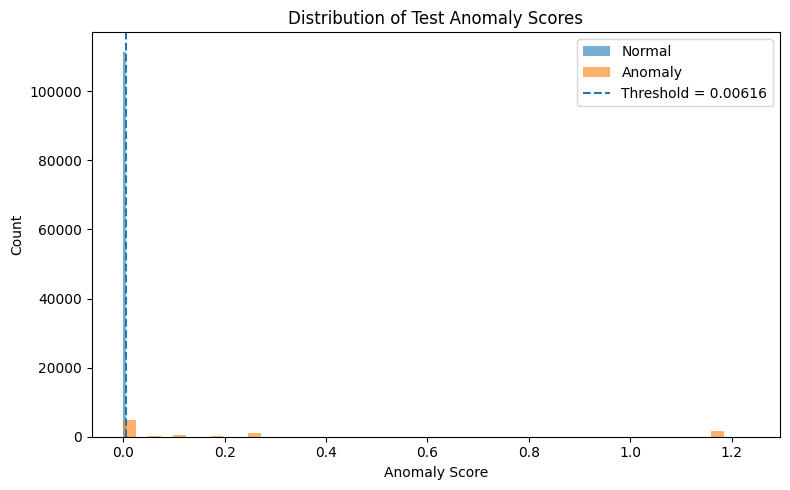

In [31]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.hist(normal_scores, bins=50, alpha=0.6, label="Normal")
plt.hist(anomaly_scores, bins=50, alpha=0.6, label="Anomaly")
plt.axvline(best_t, linestyle="--", label=f"Threshold = {best_t:.5f}")
plt.xlabel("Anomaly Score")
plt.ylabel("Count")
plt.title("Distribution of Test Anomaly Scores")
plt.legend()
plt.tight_layout()
plt.show()

# ROC Curve

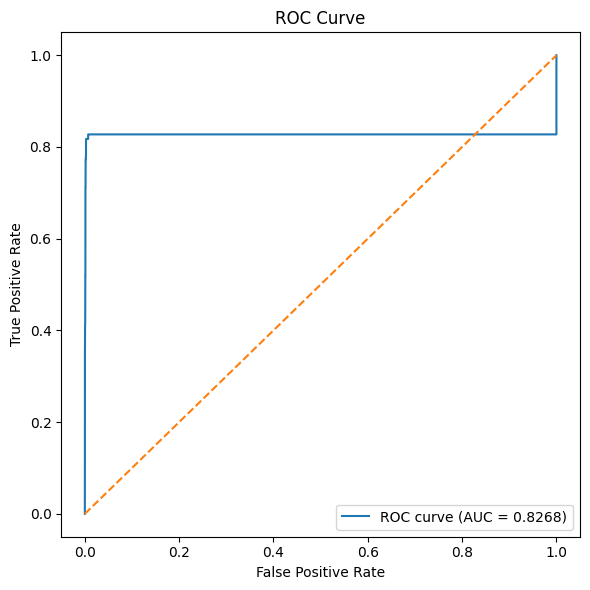

In [32]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(test_labels, test_scores)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

# BiLSTM + Transformer Models
## Model-agnostic scoring utility

In [33]:
import numpy as np

def score_group_fast_v2(lines_32, model_fn, window=30):
    """
    Model-agnostic version of score_group_fast.
    lines_32: array [N, 32]
    model_fn : compiled Keras model
    returns  : (group_score, line_scores)
    """
    lines_32 = np.asarray(lines_32, dtype=np.float32)
    n = len(lines_32)
    if n < 2:
        return 0.0, []

    contexts, targets = [], []
    for t in range(1, n):
        start = max(0, t - window)
        contexts.append(lines_32[start:t])
        targets.append(lines_32[t])

    max_len = max(ctx.shape[0] for ctx in contexts)
    x = np.zeros((len(contexts), max_len, lines_32.shape[1]), dtype=np.float32)
    for i, ctx in enumerate(contexts):
        x[i, :ctx.shape[0], :] = ctx

    y    = np.asarray(targets, dtype=np.float32)          # [B, 32]
    pred = model_fn(x, training=False).numpy()            # [B, K, 32]

    y_norm = y    / (np.linalg.norm(y,    axis=1, keepdims=True) + 1e-12)
    z_norm = pred / (np.linalg.norm(pred, axis=2, keepdims=True) + 1e-12)
    u = np.einsum("be,bke->bk", y_norm, z_norm)
    a = np.exp(u - np.max(u, axis=1, keepdims=True))
    a = a / (np.sum(a, axis=1, keepdims=True) + 1e-12)
    w = np.einsum("bk,bke->be", a, z_norm)
    w = w / (np.linalg.norm(w, axis=1, keepdims=True) + 1e-12)
    cos = np.sum(y_norm * w, axis=1)
    line_scores = (1.0 - cos).tolist()
    return float(np.max(line_scores)), line_scores


def evaluate_model(model_fn, ids, groups_32, labels, window=30, desc=""):
    """Score all groups and return (scores_array, labels_array)."""
    scores, lbls = [], []
    for i, bid in enumerate(ids):
        if i % 5000 == 0:
            print(f"{desc} scored: {i}/{len(ids)}")
        gs, _ = score_group_fast_v2(groups_32[bid], model_fn, window=window)
        scores.append(gs)
        lbls.append(labels[bid])
    return np.asarray(scores), np.asarray(lbls)


## BiLSTM Model
### Build

In [34]:
import tensorflow as tf

K = 8   # Top-K candidates (same as LSTM baseline)
E = 32  # Embedding dimension

inp_b = tf.keras.Input(shape=(None, E), dtype=tf.float32, name="seq")
x_b   = tf.keras.layers.Masking(mask_value=0.0)(inp_b)
x_b   = tf.keras.layers.Bidirectional(
            tf.keras.layers.LSTM(64, return_sequences=True),
            name="bilstm_1")(x_b)
x_b   = tf.keras.layers.Bidirectional(
            tf.keras.layers.LSTM(64, return_sequences=False),
            name="bilstm_2")(x_b)
x_b   = tf.keras.layers.Dense(K * E, activation=None, name="topk_dense")(x_b)
out_b = tf.keras.layers.Reshape((K, E), name="topk")(x_b)

bilstm_model = tf.keras.Model(inp_b, out_b, name="teledal_bilstm")
bilstm_model.summary()


Model: "teledal_bilstm"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ seq (InputLayer)    │ (None, None, 32)  │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_2         │ (None, None, 32)  │          0 │ seq[0][0]         │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ masking (Masking)   │ (None, None, 32)  │          0 │ seq[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ any_2 (Any)         │ (None, None)      │          0 │ not_equal_2[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bilstm_1            │ (None, None, 128) │     49,664 │ masking[0][0],    │
│ (Bidirectional)     │                   │            │ any_2[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bilstm_2            │ (None, 128)       │     98,816 │ bilstm_1[0][0],   │
│ (Bidirectional)     │                   │            │ any_2[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ topk_dense (Dense)  │ (None, 256)       │     33,024 │ bilstm_2[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ topk (Reshape)      │ (None, 8, 32)     │          0 │ topk_dense[0][0]  │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 181,504 (709.00 KB)

 Trainable params: 181,504 (709.00 KB)

 Non-trainable params: 0 (0.00 B)

### Compile + Train BiLSTM

In [35]:
BILSTM_MODEL_PATH = "/content/drive/MyDrive/teleDAL_bilstm_model.keras"

bilstm_model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss=topk_loss
)

ckpt_b = tf.keras.callbacks.ModelCheckpoint(
    BILSTM_MODEL_PATH, monitor="val_loss", save_best_only=True, verbose=1
)
early_b = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=2, restore_best_weights=True
)

if os.path.exists(BILSTM_MODEL_PATH):
    print("BiLSTM: saved model found – loading.")
    bilstm_model = tf.keras.models.load_model(
        BILSTM_MODEL_PATH,
        custom_objects={"topk_loss": topk_loss}
    )
else:
    print("BiLSTM: training from scratch.")
    history_b = bilstm_model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=10,
        callbacks=[ckpt_b, early_b]
    )
    bilstm_model.save(BILSTM_MODEL_PATH)
    print("BiLSTM model saved.")

bilstm_model.summary()


BiLSTM: saved model found – loading.


Model: "teledal_bilstm"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ seq (InputLayer)    │ (None, None, 32)  │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_5         │ (None, None, 32)  │          0 │ seq[0][0]         │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ masking (Masking)   │ (None, None, 32)  │          0 │ seq[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ any_5 (Any)         │ (None, None)      │          0 │ not_equal_5[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bilstm_1            │ (None, None, 128) │     49,664 │ masking[0][0],    │
│ (Bidirectional)     │                   │            │ any_5[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bilstm_2            │ (None, 128)       │     98,816 │ bilstm_1[0][0],   │
│ (Bidirectional)     │                   │            │ any_5[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ topk_dense (Dense)  │ (None, 256)       │     33,024 │ bilstm_2[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ topk (Reshape)      │ (None, 8, 32)     │          0 │ topk_dense[0][0]  │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 544,514 (2.08 MB)

 Trainable params: 181,504 (709.00 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 363,010 (1.38 MB)

### BiLSTM Test evaluation

In [36]:
BILSTM_SCORES_PATH = "/content/drive/MyDrive/teleDAL_bilstm_scores.pkl"

if os.path.exists(BILSTM_SCORES_PATH):
    print("Cached BiLSTM scores found. Loading...")
    with open(BILSTM_SCORES_PATH, "rb") as f:
        d = pickle.load(f)
    val_scores_b  = d["val_scores"]
    val_labels_b  = d["val_labels"]
    test_scores_b = d["test_scores"]
    test_labels_b = d["test_labels"]
    print("BiLSTM scores loaded.")

else:
    print("Generating BiLSTM validation scores...")
    val_scores_b, val_labels_b = evaluate_model(
        bilstm_model, val_ids, groups_32, labels, window=WINDOW, desc="BiLSTM val"
    )

    print("Generating BiLSTM test scores...")
    test_scores_b, test_labels_b = evaluate_model(
        bilstm_model, test_ids, groups_32, labels, window=WINDOW, desc="BiLSTM test"
    )

    with open(BILSTM_SCORES_PATH, "wb") as f:
        pickle.dump({
            "val_scores":  val_scores_b,
            "val_labels":  val_labels_b,
            "test_scores": test_scores_b,
            "test_labels": test_labels_b,
        }, f)
    print("BiLSTM scores saved.")

best_t_b, best_val_f1_b, best_dir_b = find_best_threshold(val_scores_b, val_labels_b)
print(f"BiLSTM – Best threshold: {best_t_b:.6f}  |  Direction: {best_dir_b}  |  Val F1: {best_val_f1_b:.4f}")

test_preds_b = (
    (test_scores_b >= best_t_b).astype(int)
    if best_dir_b == ">="
    else (test_scores_b <= best_t_b).astype(int)
)

print("=== BiLSTM Results ===")
print("Precision:", precision_score(test_labels_b, test_preds_b, zero_division=0))
print("Recall   :", recall_score   (test_labels_b, test_preds_b, zero_division=0))
print("F1       :", f1_score       (test_labels_b, test_preds_b, zero_division=0))
print("ROC-AUC  :", roc_auc_score  (test_labels_b, test_scores_b))
print()
print(classification_report(test_labels_b, test_preds_b, zero_division=0))

Cached BiLSTM scores found. Loading...
BiLSTM scores loaded.
BiLSTM – Best threshold: 0.005759  |  Direction: >=  |  Val F1: 0.6118
=== BiLSTM Results ===
Precision: 0.9727716414076548
Recall   : 0.44981589262382704
F1       : 0.6151721897335932
ROC-AUC  : 0.8298788228607389

              precision    recall  f1-score   support

           0       0.96      1.00      0.98    111645
           1       0.97      0.45      0.62      8419

    accuracy                           0.96    120064
   macro avg       0.97      0.72      0.80    120064
weighted avg       0.96      0.96      0.95    120064



## Transformer Predictor Model
### Custom layers

In [37]:
import tensorflow as tf
import numpy as np


class PositionalEncoding(tf.keras.layers.Layer):
    """Sinusoidal positional encoding – added to the token embeddings."""

    def __init__(self, max_len=512, **kwargs):
        super().__init__(**kwargs)
        self.max_len = max_len

    def call(self, x):
        seq_len = tf.shape(x)[1]
        d_model = tf.shape(x)[2]

        # Build PE on-the-fly to handle variable seq_len
        positions = tf.cast(tf.range(seq_len)[:, tf.newaxis], tf.float32)
        dims      = tf.cast(tf.range(d_model)[tf.newaxis, :], tf.float32)
        angles    = positions / tf.pow(
            10000.0, (2 * (dims // 2)) / tf.cast(d_model, tf.float32)
        )
        # Even indices ← sin, odd ← cos
        sin_enc = tf.math.sin(angles[:, 0::2])
        cos_enc = tf.math.cos(angles[:, 1::2])

        # Interleave back to d_model width
        pe = tf.reshape(
            tf.stack([sin_enc, cos_enc], axis=2),
            [seq_len, -1]
        )[:, :d_model]                             # trim to exact d_model
        pe = tf.cast(pe[tf.newaxis, :, :], x.dtype)
        return x + pe

    def compute_mask(self, inputs, mask=None):
      return mask  # pass the padding mask through unchanged

    def get_config(self):
        cfg = super().get_config()
        cfg.update({"max_len": self.max_len})
        return cfg


class TransformerBlock(tf.keras.layers.Layer):
    """
    Single Transformer encoder block:
      MultiHeadAttention → Add & Norm → FFN → Add & Norm
    Uses a causal (look-ahead) mask so the predictor cannot see future tokens.
    """

    def __init__(self, d_model, num_heads, ff_dim, dropout_rate=0.1, **kwargs):
        super().__init__(**kwargs)
        self.attn    = tf.keras.layers.MultiHeadAttention(
            num_heads=num_heads,
            key_dim=d_model // num_heads,
            dropout=dropout_rate
        )
        self.ffn     = tf.keras.Sequential([
            tf.keras.layers.Dense(ff_dim, activation="relu"),
            tf.keras.layers.Dense(d_model),
        ])
        self.norm1   = tf.keras.layers.LayerNormalization(epsilon=1e-6)
        self.norm2   = tf.keras.layers.LayerNormalization(epsilon=1e-6)
        self.drop1   = tf.keras.layers.Dropout(dropout_rate)
        self.drop2   = tf.keras.layers.Dropout(dropout_rate)
        self.d_model = d_model
        self.num_heads = num_heads
        self.ff_dim    = ff_dim
        self.dropout_rate = dropout_rate

    def call(self, x, training=False, mask=None):
        attn_out = self.attn(x, x, use_causal_mask=True, training=training)
        attn_out = self.drop1(attn_out, training=training)
        x = self.norm1(x + attn_out)

        ffn_out = self.ffn(x)
        ffn_out = self.drop2(ffn_out, training=training)
        return self.norm2(x + ffn_out)

    def get_config(self):
        cfg = super().get_config()
        cfg.update({
            "d_model": self.d_model, "num_heads": self.num_heads,
            "ff_dim": self.ff_dim,   "dropout_rate": self.dropout_rate,
        })
        return cfg


### Build Transformer Predictor

In [38]:
K      = 8
E      = 32
D_MODEL = 64    # internal Transformer width
N_HEADS = 4
FF_DIM  = 128
N_LAYERS = 2

inp_t = tf.keras.Input(shape=(None, E), dtype=tf.float32, name="seq")
x_t   = tf.keras.layers.Masking(mask_value=0.0)(inp_t)

# Project 32-dim embeddings → D_MODEL (same role as Dense(768→32) in TeleDAL)
x_t = tf.keras.layers.Dense(D_MODEL, name="embed_proj")(x_t)
x_t = PositionalEncoding(name="pos_enc")(x_t)
x_t = tf.keras.layers.Dropout(0.1)(x_t)

for i in range(N_LAYERS):
    x_t = TransformerBlock(D_MODEL, N_HEADS, FF_DIM, dropout_rate=0.1,
                            name=f"transformer_block_{i}")(x_t)

# Take the last token's representation (autoregressive prediction)
x_t = x_t[:, -1, :]   # [B, D_MODEL]

x_t   = tf.keras.layers.Dense(K * E, activation=None, name="topk_dense")(x_t)
out_t = tf.keras.layers.Reshape((K, E), name="topk")(x_t)

transformer_model = tf.keras.Model(inp_t, out_t, name="teledal_transformer")
transformer_model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:982: UserWarning: Layer 'transformer_block_0' (of type TransformerBlock) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


Model: "teledal_transformer"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ seq (InputLayer)    │ (None, None, 32)  │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ masking_1 (Masking) │ (None, None, 32)  │          0 │ seq[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embed_proj (Dense)  │ (None, None, 64)  │      2,112 │ masking_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pos_enc             │ (None, None, 64)  │          0 │ embed_proj[0][0]  │
│ (PositionalEncodin… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_4         │ (None, None, 32)  │          0 │ seq[0][0]         │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, None, 64)  │          0 │ pos_enc[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ any_4 (Any)         │ (None, None)      │          0 │ not_equal_4[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_block_0 │ (None, None, 64)  │     33,472 │ dropout[0][0],    │
│ (TransformerBlock)  │                   │            │ any_4[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_block_1 │ (None, None, 64)  │     33,472 │ transformer_bloc… │
│ (TransformerBlock)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 64)        │          0 │ transformer_bloc… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ topk_dense (Dense)  │ (None, 256)       │     16,640 │ get_item[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ topk (Reshape)      │ (None, 8, 32)     │          0 │ topk_dense[0][0]  │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 85,696 (334.75 KB)

 Trainable params: 85,696 (334.75 KB)

 Non-trainable params: 0 (0.00 B)

### Compile + Train Transformer

In [39]:
TRANSFORMER_MODEL_PATH = "/content/drive/MyDrive/teleDAL_transformer_model.keras"

transformer_model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss=topk_loss
)

ckpt_t = tf.keras.callbacks.ModelCheckpoint(
    TRANSFORMER_MODEL_PATH, monitor="val_loss", save_best_only=True, verbose=1
)
early_t = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=2, restore_best_weights=True
)

if os.path.exists(TRANSFORMER_MODEL_PATH):
    print("Transformer: saved model found – loading.")
    transformer_model = tf.keras.models.load_model(
        TRANSFORMER_MODEL_PATH,
        custom_objects={
            "topk_loss": topk_loss,
            "PositionalEncoding": PositionalEncoding,
            "TransformerBlock": TransformerBlock,
        }
    )
else:
    print("Transformer: training from scratch.")
    history_t = transformer_model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=10,
        callbacks=[ckpt_t, early_t]
    )
    transformer_model.save(TRANSFORMER_MODEL_PATH)
    print("Transformer model saved.")

transformer_model.summary()


Transformer: saved model found – loading.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:424: UserWarning: `build()` was called on layer 'transformer_block_0', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:424: UserWarning: `build()` was called on layer 'transformer_block_1', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


Model: "teledal_transformer"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ seq (InputLayer)    │ (None, None, 32)  │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ masking_1 (Masking) │ (None, None, 32)  │          0 │ seq[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embed_proj (Dense)  │ (None, None, 64)  │      2,112 │ masking_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pos_enc             │ (None, None, 64)  │          0 │ embed_proj[0][0]  │
│ (PositionalEncodin… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_6         │ (None, None, 32)  │          0 │ seq[0][0]         │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, None, 64)  │          0 │ pos_enc[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ any_6 (Any)         │ (None, None)      │          0 │ not_equal_6[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_block_0 │ (None, None, 64)  │     33,472 │ dropout[0][0],    │
│ (TransformerBlock)  │                   │            │ any_6[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_block_1 │ (None, None, 64)  │     33,472 │ transformer_bloc… │
│ (TransformerBlock)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 64)        │          0 │ transformer_bloc… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ topk_dense (Dense)  │ (None, 256)       │     16,640 │ get_item[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ topk (Reshape)      │ (None, 8, 32)     │          0 │ topk_dense[0][0]  │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 257,090 (1004.26 KB)

 Trainable params: 85,696 (334.75 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 171,394 (669.51 KB)

### Transformer Validation → best threshold

In [40]:
TRANSFORMER_SCORES_PATH = "/content/drive/MyDrive/teleDAL_transformer_scores.pkl"

if os.path.exists(TRANSFORMER_SCORES_PATH):
    print("Cached Transformer scores found. Loading...")
    with open(TRANSFORMER_SCORES_PATH, "rb") as f:
        d = pickle.load(f)
    val_scores_t  = d["val_scores"]
    val_labels_t  = d["val_labels"]
    test_scores_t = d["test_scores"]
    test_labels_t = d["test_labels"]
    print("Transformer scores loaded.")

else:
    print("Generating Transformer validation scores...")
    val_scores_t, val_labels_t = evaluate_model(
        transformer_model, val_ids, groups_32, labels, window=WINDOW, desc="Transformer val"
    )

    print("Generating Transformer test scores...")
    test_scores_t, test_labels_t = evaluate_model(
        transformer_model, test_ids, groups_32, labels, window=WINDOW, desc="Transformer test"
    )

    with open(TRANSFORMER_SCORES_PATH, "wb") as f:
        pickle.dump({
            "val_scores":  val_scores_t,
            "val_labels":  val_labels_t,
            "test_scores": test_scores_t,
            "test_labels": test_labels_t,
        }, f)
    print("Transformer scores saved.")

best_t_t, best_val_f1_t, best_dir_t = find_best_threshold(val_scores_t, val_labels_t)
print(f"Transformer – Best threshold: {best_t_t:.6f}  |  Direction: {best_dir_t}  |  Val F1: {best_val_f1_t:.4f}")

test_preds_t = (
    (test_scores_t >= best_t_t).astype(int)
    if best_dir_t == ">="
    else (test_scores_t <= best_t_t).astype(int)
)

print("=== Transformer Results ===")
print("Precision:", precision_score(test_labels_t, test_preds_t, zero_division=0))
print("Recall   :", recall_score   (test_labels_t, test_preds_t, zero_division=0))
print("F1       :", f1_score       (test_labels_t, test_preds_t, zero_division=0))
print("ROC-AUC  :", roc_auc_score  (test_labels_t, test_scores_t))
print()
print(classification_report(test_labels_t, test_preds_t, zero_division=0))

Generating Transformer validation scores...
Transformer val scored: 0/120064
Transformer val scored: 5000/120064
Transformer val scored: 10000/120064
Transformer val scored: 15000/120064
Transformer val scored: 20000/120064
Transformer val scored: 25000/120064
Transformer val scored: 30000/120064
Transformer val scored: 35000/120064
Transformer val scored: 40000/120064
Transformer val scored: 45000/120064
Transformer val scored: 50000/120064
Transformer val scored: 55000/120064
Transformer val scored: 60000/120064
Transformer val scored: 65000/120064
Transformer val scored: 70000/120064
Transformer val scored: 75000/120064
Transformer val scored: 80000/120064
Transformer val scored: 85000/120064
Transformer val scored: 90000/120064
Transformer val scored: 95000/120064
Transformer val scored: 100000/120064
Transformer val scored: 105000/120064
Transformer val scored: 110000/120064


/usr/local/lib/python3.12/dist-packages/keras/src/ops/nn.py:947: UserWarning: You are using a softmax over axis 3 of a tensor of shape (1, 4, 1, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


Transformer val scored: 115000/120064
Transformer val scored: 120000/120064
Generating Transformer test scores...
Transformer test scored: 0/120064
Transformer test scored: 5000/120064
Transformer test scored: 10000/120064
Transformer test scored: 15000/120064
Transformer test scored: 20000/120064
Transformer test scored: 25000/120064
Transformer test scored: 30000/120064
Transformer test scored: 35000/120064
Transformer test scored: 40000/120064
Transformer test scored: 45000/120064
Transformer test scored: 50000/120064
Transformer test scored: 55000/120064
Transformer test scored: 60000/120064
Transformer test scored: 65000/120064
Transformer test scored: 70000/120064
Transformer test scored: 75000/120064
Transformer test scored: 80000/120064
Transformer test scored: 85000/120064
Transformer test scored: 90000/120064
Transformer test scored: 95000/120064
Transformer test scored: 100000/120064
Transformer test scored: 105000/120064
Transformer test scored: 110000/120064
Transformer te

## Model Comparison
### Metrics table

In [41]:
import pandas as pd
from sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score

results = {}

for name, ts, tl, tp in [
    ("LSTM (baseline)",  test_scores,   test_labels,   test_preds),
    ("BiLSTM",           test_scores_b, test_labels_b, test_preds_b),
    ("Transformer",      test_scores_t, test_labels_t, test_preds_t),
]:
    results[name] = {
        "Precision": round(precision_score(tl, tp, zero_division=0), 4),
        "Recall"   : round(recall_score   (tl, tp, zero_division=0), 4),
        "F1"       : round(f1_score       (tl, tp, zero_division=0), 4),
        "ROC-AUC"  : round(roc_auc_score  (tl, ts),                  4),
    }

df_results = pd.DataFrame(results).T
print(df_results.to_string())


                 Precision  Recall      F1  ROC-AUC
LSTM (baseline)     0.9747  0.7674  0.8587   0.8268
BiLSTM              0.9728  0.4498  0.6152   0.8299
Transformer         0.9983  0.3453  0.5131   0.8815


### ROC Curve Overlay

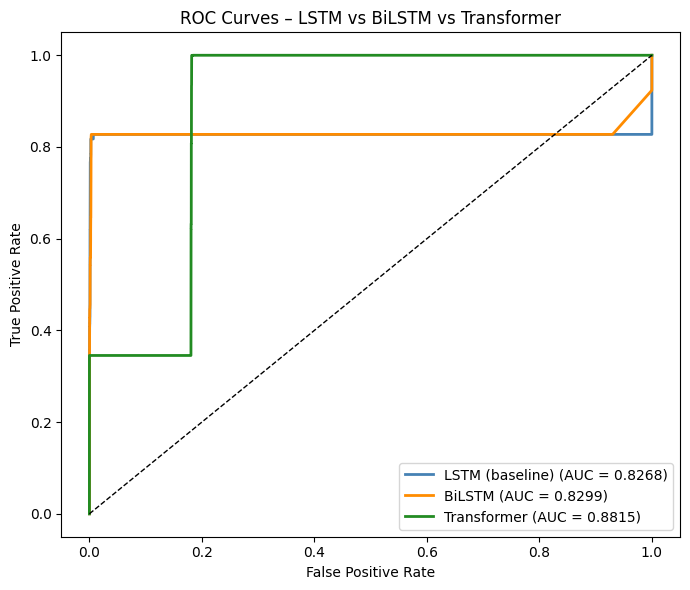

In [42]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

fig, ax = plt.subplots(figsize=(7, 6))

for name, ts, tl, color in [
    ("LSTM (baseline)",  test_scores,   test_labels,   "steelblue"),
    ("BiLSTM",           test_scores_b, test_labels_b, "darkorange"),
    ("Transformer",      test_scores_t, test_labels_t, "forestgreen"),
]:
    fpr, tpr, _ = roc_curve(tl, ts)
    roc_auc_val = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, lw=2,
            label=f"{name} (AUC = {roc_auc_val:.4f})")

ax.plot([0, 1], [0, 1], "k--", lw=1)
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curves – LSTM vs BiLSTM vs Transformer")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()


### Anomaly Score Distribution (all 3 models)

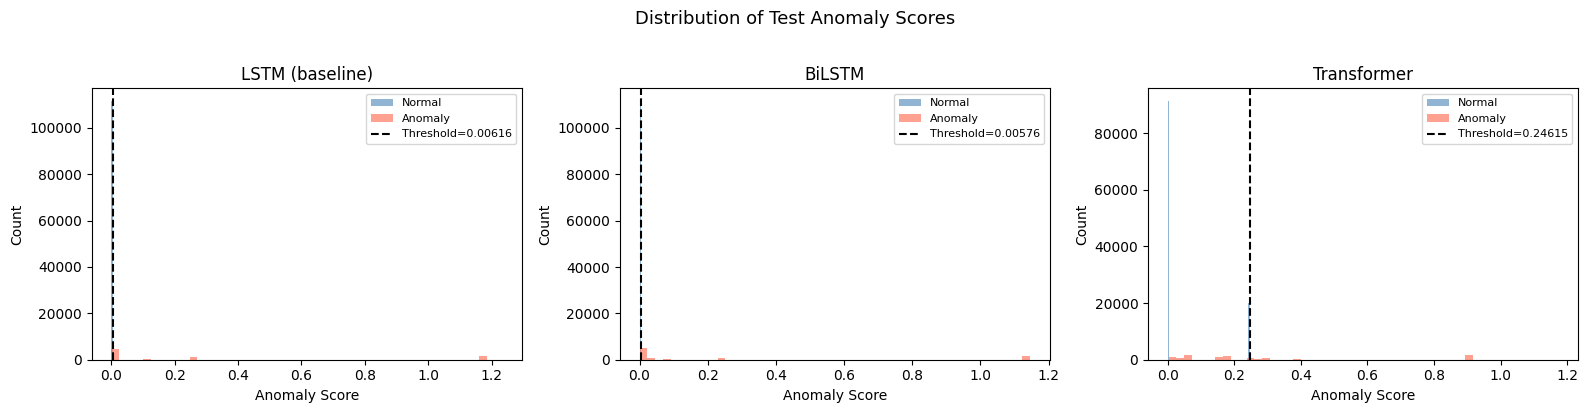

In [43]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=False)

for ax, (name, ts, tl, best_thresh) in zip(axes, [
    ("LSTM (baseline)",  test_scores,   test_labels,   best_t),
    ("BiLSTM",           test_scores_b, test_labels_b, best_t_b),
    ("Transformer",      test_scores_t, test_labels_t, best_t_t),
]):
    normal_s  = ts[tl == 0]
    anomaly_s = ts[tl == 1]
    ax.hist(normal_s,  bins=50, alpha=0.6, label="Normal",  color="steelblue")
    ax.hist(anomaly_s, bins=50, alpha=0.6, label="Anomaly", color="tomato")
    ax.axvline(best_thresh, color="black", linestyle="--", label=f"Threshold={best_thresh:.5f}")
    ax.set_title(name)
    ax.set_xlabel("Anomaly Score")
    ax.set_ylabel("Count")
    ax.legend(fontsize=8)

plt.suptitle("Distribution of Test Anomaly Scores", y=1.02, fontsize=13)
plt.tight_layout()
plt.show()


### Backup all models to Google Drive

In [44]:
import shutil

DRIVE_DIR = "/content/drive/MyDrive/teleDAL_backup/"
os.makedirs(DRIVE_DIR, exist_ok=True)

for src, dst_name in [
    (MODEL_PATH,            "teleDAL_lstm.keras"),
    (BILSTM_MODEL_PATH,     "teleDAL_bilstm.keras"),
    (TRANSFORMER_MODEL_PATH,"teleDAL_transformer.keras"),
]:
    if os.path.exists(src):
        shutil.copy(src, os.path.join(DRIVE_DIR, dst_name))
        print(f"Backed up {dst_name}")
    else:
        print(f"Skipped (not found): {src}")

print("Backup complete.")


Backed up teleDAL_lstm.keras
Backed up teleDAL_bilstm.keras
Backed up teleDAL_transformer.keras
Backup complete.


# Backup Files

In [45]:
import os
import pickle
import shutil

DRIVE_DIR = "/content/drive/MyDrive/teleDAL_backup/"
os.makedirs(DRIVE_DIR, exist_ok=True)

print("Saving backup files to:", DRIVE_DIR)

# Save embedded groups (MOST IMPORTANT)
with open(DRIVE_DIR + "groups_32.pkl", "wb") as f:
    pickle.dump(groups_32, f, protocol=pickle.HIGHEST_PROTOCOL)

print("Saved groups_32.pkl")

# Save labels
with open(DRIVE_DIR + "labels.pkl", "wb") as f:
    pickle.dump(labels, f)

print("Saved labels.pkl")

# Save dataset splits
with open(DRIVE_DIR + "train_ids.pkl", "wb") as f:
    pickle.dump(train_ids, f)

with open(DRIVE_DIR + "val_ids.pkl", "wb") as f:
    pickle.dump(val_ids, f)

with open(DRIVE_DIR + "test_ids.pkl", "wb") as f:
    pickle.dump(test_ids, f)

print("Saved dataset splits")

# Save anomaly scores (if already computed)
try:
    with open(DRIVE_DIR + "val_scores.pkl", "wb") as f:
        pickle.dump(val_scores, f)
    print("Saved val_scores.pkl")
except:
    print("val_scores not available yet")

try:
    with open(DRIVE_DIR + "test_scores.pkl", "wb") as f:
        pickle.dump(test_scores, f)
    print("Saved test_scores.pkl")
except:
    print("test_scores not available yet")

# Save threshold (if already computed)
try:
    with open(DRIVE_DIR + "threshold.pkl", "wb") as f:
        pickle.dump(best_t, f)
    print("Saved threshold.pkl")
except:
    print("Threshold not available yet")

# Copy trained model
MODEL_PATH = "/content/drive/MyDrive/teleDAL_model.keras"
BACKUP_MODEL_PATH = DRIVE_DIR + "teleDAL_model.keras"

if os.path.exists(MODEL_PATH):
    shutil.copy(MODEL_PATH, BACKUP_MODEL_PATH)
    print("Copied teleDAL_model.keras to backup folder")
else:
    print("Model file not found")

print("Backup complete.")

Saving backup files to: /content/drive/MyDrive/teleDAL_backup/
Saved groups_32.pkl
Saved labels.pkl
Saved dataset splits
Saved val_scores.pkl
Saved test_scores.pkl
Saved threshold.pkl
Copied teleDAL_model.keras to backup folder
Backup complete.
